# Main

In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils


In [2]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.use_score_clipping = False 
config.plat_scaling = True

def nll_loss(preds, target):
    pred_mean = preds[:,0]
    pred_sigma = preds[:,1]
    pred_sigma = torch.clip(torch.exp(pred_sigma), min=1e-4, max=1e10)
    square = torch.square(pred_mean - target)
    return torch.mean(torch.divide(square, pred_sigma) + torch.log(pred_sigma))

class NLLRegressionMetricLogger(utils.MetricLogger):
    def __init__(self, t=1.):
        super().__init__()
        self.t = t

    def reset(self):
        self._losses = []
        self._l2s = []
        self._set_sizes = []
        self._hits = []
        self._all_preds = []
        self._all_labels = []

    def update(self, pred_scores, true_scores):
        pred_scores = pred_scores[:,0].squeeze().detach().cpu()
        true_scores = true_scores.detach().cpu()

        self._all_labels += true_scores.numpy().tolist()
        self._all_preds += pred_scores.numpy().tolist()
        self._l2s += (torch.abs(pred_scores - true_scores)**2).numpy().tolist()

    def calc(self):
        return {'loss': np.mean(self._losses),
                'r^2': utils.calc_r2(np.asarray(self._all_labels),
                               np.asarray(self._all_preds)),
                'l2':  np.mean(self._l2s)}

def split_by_thresh(dl, thresh, fold_name, batch_size=config.batch_size):
    ds = dl.dataset
    probs = ds.cls_probs.numpy()

    above_inds = np.where(probs.max(1) >= thresh)[0]
    below_inds = np.where(probs.max(1) < thresh)[0]
    above_ds = torch.utils.data.Subset(ds, above_inds)
    below_ds = torch.utils.data.Subset(ds, below_inds)
    print(f'Split with thresh: {thresh} to {len(above_ds)}/{len(below_ds)}')
    above_ds = torch.utils.data.DataLoader(above_ds, batch_size=batch_size, shuffle=True if fold_name == 'train' else False, pin_memory=True)
    below_ds = torch.utils.data.DataLoader(below_ds, batch_size=batch_size, shuffle=True if fold_name == 'train' else False, pin_memory=True)
    return above_ds, below_ds

In [3]:
utils.seed_everything(config.seed)
utils.create_logger(config.exp_dir, config.dump_log)

logging.info('Config:')
for k, v in config.items():
    logging.info(f'{k}: {v}')
logging.info('')

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(valid_dl, test_dl, alpha=config.alpha, k_raps=config.k_raps)

from sklearn.decomposition import PCA
train_embeds = train_dl.dataset.embeds.numpy()
valid_embeds = valid_dl.dataset.embeds.numpy()
test_embeds = test_dl.dataset.embeds.numpy()
pca = PCA(n_components=100)
pca_embeds = torch.FloatTensor(pca.fit_transform(np.concatenate([train_embeds, valid_embeds, test_embeds])))
pca_embeds = torch.split(pca_embeds, split_size_or_sections=[len(train_embeds), len(valid_embeds), len(test_embeds)])
train_dl.dataset.embeds = pca_embeds[0]
valid_dl.dataset.embeds = pca_embeds[1]
test_dl.dataset.embeds = pca_embeds[2]
print(np.sum(pca.explained_variance_ratio_))

thresh = 1. - config.alpha
above_train_dl, below_train_dl = split_by_thresh(train_dl, thresh, 'train')
above_valid_dl, below_valid_dl = split_by_thresh(valid_dl, thresh, 'valid')
above_test_dl, below_test_dl = split_by_thresh(test_dl, thresh, 'test')

below_baseline_mets = calc_baseline_mets(below_valid_dl, below_test_dl, alpha=config.alpha, k_raps=config.k_raps)
above_baseline_mets = calc_baseline_mets(above_valid_dl, above_test_dl, alpha=config.alpha, k_raps=config.k_raps)

INFO - 03/17/24 07:49:09 - 0:00:00 - Created main log at tmp/net_launcher_log.log
INFO - 03/17/24 07:49:09 - 0:00:00 - Config:
INFO - 03/17/24 07:49:09 - 0:00:00 - alpha: 0.1
INFO - 03/17/24 07:49:09 - 0:00:00 - batch_size: 128
INFO - 03/17/24 07:49:09 - 0:00:00 - comments: 
INFO - 03/17/24 07:49:09 - 0:00:00 - conformal_module_name: aps
INFO - 03/17/24 07:49:09 - 0:00:00 - criteria_name: mse
INFO - 03/17/24 07:49:09 - 0:00:00 - dataset_name: tissuemnist
INFO - 03/17/24 07:49:09 - 0:00:00 - device: cuda:0
INFO - 03/17/24 07:49:09 - 0:00:00 - drop_rate: 0.0
INFO - 03/17/24 07:49:09 - 0:00:00 - dump_log: False
INFO - 03/17/24 07:49:09 - 0:00:00 - exp_dir: tmp
INFO - 03/17/24 07:49:09 - 0:00:00 - file_name: /home/royhirsch/conformal/data/embeds_n_logits/aug/medmnist/tissuemnist_test.pickle
INFO - 03/17/24 07:49:09 - 0:00:00 - gpu_num: 0
INFO - 03/17/24 07:49:09 - 0:00:00 - hidden_dim: 512
INFO - 03/17/24 07:49:09 - 0:00:00 - input_dim: 2048
INFO - 03/17/24 07:49:09 - 0:00:00 - k_raps: 5
I

0.9887722
Split with thresh: 0.9 to 8879/30836
Split with thresh: 0.9 to 834/2948
Split with thresh: 0.9 to 881/2901


In [4]:
config.lr = 1e-3
config.wd = 1e-2
config.num_epochs = 60

def train(train_dl, valid_dl, test_dl):
    model = NN(input_dim=100,
               hidden_dim=[64, 32],
               out_dim=2,
               norm=config.norm,
               drop_rate=0.0,
               criteria_name=config.criteria_name)
    model = model.to(config.device)
    logging.info(model)

    optimizer = get_optimizer(model, config)
    scheduler = get_scheduler(optimizer, config)

    criteria = nll_loss
    trainer = Trainer(criteria=criteria,
                      metric_logger=NLLRegressionMetricLogger,
                      config=config,
                      input_key='embeds')

    trainer.fit(model=model,
                train_loader=train_dl,
                test_loader=test_dl,
                optimizer=optimizer,
                scheduler=scheduler,
                valid_loader=valid_dl)
    
    train_predict_out = trainer.predict(model, train_dl)
    valid_predict_out = trainer.predict(model, valid_dl)
    test_predict_out = trainer.predict(model, test_dl)
    outs = {
        'train': train_predict_out,
        'valid': valid_predict_out,
        'test': test_predict_out,
        }
    return model, trainer.history, outs

below_model, below_history, below_outs = train(below_train_dl, below_valid_dl, below_test_dl)
above_model, above_history, above_outs = train(above_train_dl, above_valid_dl, above_test_dl)

INFO - 03/17/24 07:49:19 - 0:00:10 - NN(
                                       (layers): Sequential(
                                         (0): Linear(in_features=100, out_features=64, bias=True)
                                         (1): ReLU()
                                         (2): Linear(in_features=64, out_features=32, bias=True)
                                         (3): ReLU()
                                         (4): Linear(in_features=32, out_features=2, bias=True)
                                       )
                                     )
INFO - 03/17/24 07:49:19 - 0:00:10 - Label transform: none
INFO - 03/17/24 07:49:19 - 0:00:10 - Start training for 60 epochs:
INFO - 03/17/24 07:49:19 - 0:00:10 - Number of batches in train epoch: 241
  0%|          | 0/60 [00:00<?, ?it/s]INFO - 03/17/24 07:49:19 - 0:00:10 - E 1/60 |
INFO - 03/17/24 07:49:21 - 0:00:11 - E1-Train: loss=-1.7334 | r^2=-1.5328 | l2=0.0831
  2%|▏         | 1/60 [00:01<01:13,  1.25s/it]INFO

# Analize model

0.2906650024579761 0.2037597018838896


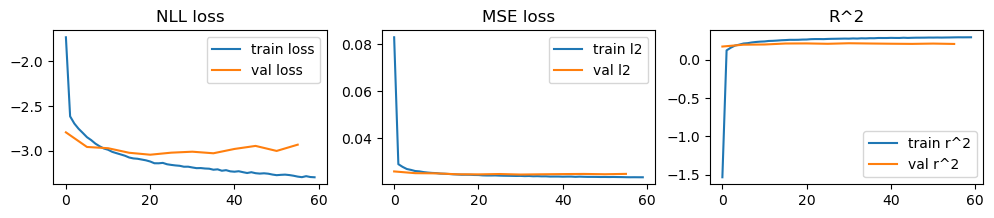

In [5]:
import matplotlib.pyplot as plt
import numpy as np

history = below_history
x_val = np.arange(0, len(history['loss']), config.val_interval)

plt.figure(figsize=(12,2))
plt.subplot(1,3,1)
plt.plot(history['loss'], label='train loss')
plt.plot(x_val, history['val_loss'], label='val loss')
plt.title('NLL loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history['l2'], label='train l2')
plt.plot(x_val, history['val_l2'], label='val l2')
plt.title('MSE loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(history['r^2'], label='train r^2')
plt.plot(x_val, history['val_r^2'], label='val r^2')
plt.title('R^2')
plt.legend()

print(history['r^2'][-1], history['val_r^2'][-1])

In [6]:
def eval(model, dl):
    y_test_all = []
    pred_mean_test_all = []
    pred_sigma_test_all = []
    model.eval()
    with torch.no_grad():
        for batch in dl:

            inp = batch['embeds'].to(config.device)
            label = batch['scores'].to(config.device)

            preds = model(inp)
            
            y_test_all += label.squeeze().detach().cpu().numpy().tolist()
            pred_mean_test_all += preds[:,0].squeeze().detach().cpu().numpy().tolist()
            pred_sigma_test_all += preds[:,1].squeeze().detach().cpu().numpy().tolist()

    y_test_all = np.asarray(y_test_all)
    pred_mean_test_all = np.asarray(pred_mean_test_all)
    pred_sigma_test_all = np.asarray(pred_sigma_test_all)
    pred_sigma_test_all = np.exp(pred_sigma_test_all)
    return y_test_all, pred_mean_test_all, pred_sigma_test_all

# train_y, train_pred_mean, train_pred_sigma = eval(below_model, below_train_dl)
# test_y, test_pred_mean, test_pred_sigma = eval(below_model, below_test_dl)

train_y, train_pred_mean, train_pred_sigma = eval(above_model, above_train_dl)
test_y, test_pred_mean, test_pred_sigma = eval(above_model, above_test_dl)


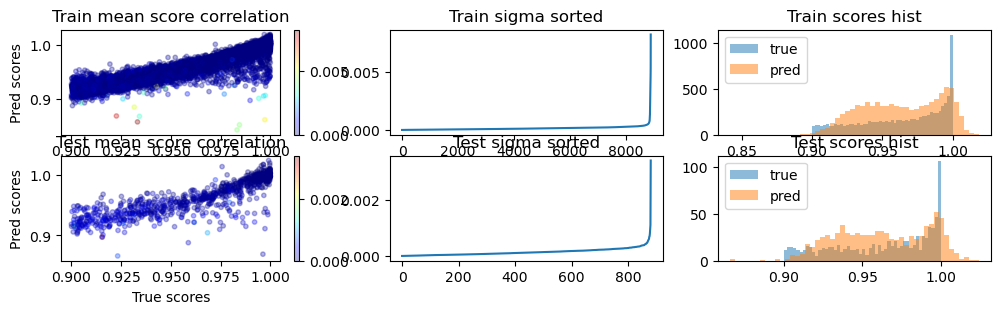

In [7]:
plt.figure(figsize=(12,3))

plt.subplot(2,3,1)
hist, edges = np.histogram(train_pred_sigma, bins=50)
hist = hist / hist.sum()
c = np.digitize(train_pred_sigma, edges[1:-1])
c = (c - np.min(c)) / (np.max(c) - np.min(c)) * np.max(train_pred_sigma)
plt.scatter(train_y, train_pred_mean, s=10, alpha=0.3, c=c, cmap='jet')
plt.colorbar()
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Train mean score correlation')

plt.subplot(2,3,2)
plt.plot(sorted(train_pred_sigma))
plt.title('Train sigma sorted')

plt.subplot(2,3,3)
_ = plt.hist(train_y, bins=50, label='true', alpha=0.5)
_ = plt.hist(train_pred_mean, bins=50, label='pred', alpha=0.5)
plt.legend()
plt.title('Train scores hist')

plt.subplot(2,3,4)
hist, edges = np.histogram(test_pred_sigma, bins=50)
hist = hist / hist.sum()
c = np.digitize(test_pred_sigma, edges[1:-1])
c = (c - np.min(c)) / (np.max(c) - np.min(c)) * np.max(test_pred_sigma)
plt.scatter(test_y, test_pred_mean, s=10, alpha=0.3, c=c, cmap='jet')
plt.colorbar()
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Test mean score correlation')

plt.subplot(2,3,5)
plt.plot(sorted(test_pred_sigma))
plt.title('Test sigma sorted')

plt.subplot(2,3,6)
_ = plt.hist(test_y, bins=50, label='true', alpha=0.5)
_ = plt.hist(test_pred_mean, bins=50, label='pred', alpha=0.5)
plt.legend()
plt.title('Test scores hist')

plt.show()


# Conformalization

In [8]:
import numpy as np

alpha = 0.1
eps = 1e-6
max_value = 1.0 - eps

def quantize(preds, probs):
    quantize_scores = []
    for prob, pred in zip(probs, preds):
        cumsum = np.sort(prob)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - pred))
        quantize_scores.append(cumsum[ind])
    return np.asarray(quantize_scores)

def calc_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)

    print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                                prediction_sets[np.arange(m), labels].mean()))
    return prediction_sets.sum(1).mean()


In [9]:
outs = {}
for k in below_outs:
    outs[k] = {}
    for kk in below_outs[k]:
        outs[k][kk] = np.concatenate([below_outs[k][kk], above_outs[k][kk]])

train_predict_out = outs['valid']
test_predict_out = outs['test']

calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores'][:,0]
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_true_labels = test_predict_out['cls_labels']
valid_pred_scores = test_predict_out['pred_scores'][:,0]
valid_probs = test_predict_out['cls_probs']

calib_pred_scores = np.minimum(calib_pred_scores, max_value - eps)
valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
# calib_pred_scores = quantize(calib_pred_scores, calib_probs)
# valid_pred_scores = quantize(valid_pred_scores, valid_probs)

diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = calib_true_scores - calib_pred_scores

# diff = diff[np.where(calib_pred_scores<global_qhat)[0]]
n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)
calc_mets(valid_probs, modified_valid_pred_scores, test_predict_out['cls_labels'])


Residuals correction is 0.56678968, clip 19.62% of the samples
mean size 3.300 | acc 0.902


3.299576943416182

# Filter by confidence

In [10]:
def get_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)
    return prediction_sets.sum(1).mean(), prediction_sets[np.arange(m), labels].mean()

use 5.09%/5.03% of the samples
use 36.60%/36.19% of the samples
use 52.78%/52.84% of the samples
use 67.27%/69.15% of the samples
use 80.66%/81.56% of the samples
use 89.89%/90.11% of the samples
use 95.28%/95.35% of the samples
use 98.03%/97.83% of the samples


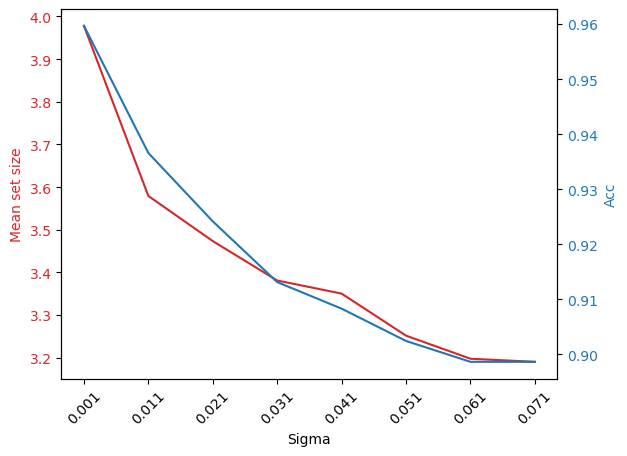

In [11]:
import matplotlib.pyplot as plt

sig2m = {}
sig2acc = {}
sigma_range = np.arange(0.001,0.08,0.01)
# sigma_range = np.asarray([0.005, 0.006, 0.007])
# sigma_range = np.asarray([0.012, 0.014])

for sigma_thresh in sigma_range:
    # train_predict_out = below_outs['train']
    train_predict_out = below_outs['valid']
    test_predict_out = below_outs['test']

    # max_value = conformal_module.get_max_value(8)
    calib_pred_sigma = np.exp(train_predict_out['pred_scores'][:,1])
    calib_inds = np.where(calib_pred_sigma<sigma_thresh)[0]

    calib_true_scores = train_predict_out['true_scores'][calib_inds]
    calib_pred_scores = train_predict_out['pred_scores'][calib_inds,0]
    calib_probs = train_predict_out['cls_probs'][calib_inds]

    valid_pred_sigma = np.exp(test_predict_out['pred_scores'][:,1])
    valid_inds = np.where(valid_pred_sigma<sigma_thresh)[0]
    print(f'use {len(calib_inds)/len(calib_pred_sigma)*100:.2f}%/{len(valid_inds) / len(valid_pred_sigma)*100:.2f}% of the samples')

    valid_true_scores = test_predict_out['true_scores'][valid_inds]
    valid_true_labels = test_predict_out['cls_labels'][valid_inds]
    valid_pred_scores = test_predict_out['pred_scores'][valid_inds,0]
    valid_probs = test_predict_out['cls_probs'][valid_inds]

    calib_pred_scores = np.minimum(calib_pred_scores, max_value - eps)
    valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
    # calib_pred_scores = quantize(calib_pred_scores, calib_probs)
    # valid_pred_scores = quantize(valid_pred_scores, valid_probs)

    diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
    # diff = calib_true_scores - calib_pred_scores

    # diff = diff[np.where(calib_pred_scores<global_qhat)[0]]
    n = len(diff)
    qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

    modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
    # modified_valid_pred_scores = valid_pred_scores + qhat

    n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
    modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)

    scores = np.full_like(test_predict_out['true_scores'], 0.9863331)
    scores[valid_inds] = modified_valid_pred_scores
    m, acc = get_mets(test_predict_out['cls_probs'], scores, test_predict_out['cls_labels'])
    sig2m[sigma_thresh] = m
    sig2acc[sigma_thresh] = acc
    
fig, ax1 = plt.subplots()
x = np.arange(len(sig2acc))

color = 'tab:red'
ax1.set_xlabel('Sigma')
ax1.set_xticks(x, sigma_range.round(4), rotation=45)
ax1.set_ylabel('Mean set size', color=color)
ax1.plot(x, sig2m.values(), color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Acc', color=color)
ax2.plot(x, sig2acc.values(), color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

In [12]:
k = 0.071
sig2m[k], sig2acc[k]

(3.1902792140641156, 0.8986556359875905)

Text(0.5, 1.0, 'Sigma dist')

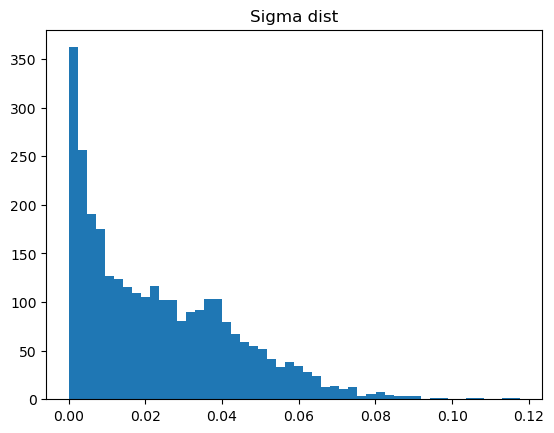

In [13]:
_ = plt.hist(calib_pred_sigma,bins=50)
plt.title('Sigma dist')

In [14]:
import copy


def get_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)
    return prediction_sets.sum(1).mean(), prediction_sets[np.arange(m), labels].mean()

sig2m = {}
sig2acc = {}
sigma_range = np.arange(0,0.1,0.005)
for sigma_thresh in sigma_range:
    valid_pred_sigma = np.exp(test_predict_out['pred_scores'][:,1])
    inds = np.where(valid_pred_sigma>sigma_thresh)[0]
    # print(f'There are {len(inds)} ({len(inds)/len(valid_pred_sigma)*100:.2f}%) items with sigma above ({sigma_thresh})')
    interleave_valid_scores = copy.deepcopy(modified_valid_pred_scores)
    interleave_valid_scores[inds] = 0.9863331
    m, acc = get_mets(valid_probs, interleave_valid_scores, valid_true_labels)
    sig2m[sigma_thresh] = m
    sig2acc[sigma_thresh] = acc
    
fig, ax1 = plt.subplots()
x = np.arange(len(sig2acc))

color = 'tab:red'
ax1.set_xlabel('Sigma')
ax1.set_xticks(x, sigma_range, rotation=45)
ax1.set_ylabel('Mean set size', color=color)
ax1.plot(x, sig2m.values(), color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Acc', color=color)
ax2.plot(x, sig2acc.values(), color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()


IndexError: index 2838 is out of bounds for axis 0 with size 2838

In [ ]:
baseline_mets['aps']

{'size_mean': 3.4865150713907984,
 'size_std': 1.8546333326802822,
 'qhat': 0.9873722,
 'acc': 0.9013749338974087}